# ✅ Musterlösung: Hands-On Chronos

Vollständige Lösung zu `2_chronos_handson_students.ipynb`. Aufgabe 1, 2a und 2b ausgefüllt, mit kurzen Begründungen.

---
## 0 · Setup & Daten

*Die Daten werden **identisch zur Prophet-Handson-Übung** erzeugt (gleicher Seed, 2020-2023, eine Black-Friday-Spitze pro Jahr), damit beide Notebooks direkt vergleichbar sind.*


In [1]:
import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from chronos import BaseChronosPipeline
np.random.seed(0); torch.manual_seed(0)

def print_metrics(y_true, y_pred, label='Modell'):
    y_true = np.asarray(y_true, float); y_pred = np.asarray(y_pred, float)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    print(f'{label:<28} RMSE={rmse:8.1f}  MAE={mae:8.1f}  MAPE={mape:5.1f}%')
    return {'label': label, 'RMSE': rmse, 'MAE': mae, 'MAPE': mape}

def plot_forecast(y_train, y_true, median, lo, hi, label, n_context=90):
    H = len(y_true)
    xh = np.arange(-min(n_context, len(y_train)), 0); xf = np.arange(0, H)
    plt.figure(figsize=(13, 4))
    plt.plot(xh, y_train[-len(xh):], color='gray', label='Historie')
    plt.plot(xf, y_true, color='black', marker='.', label='Test (echt)')
    plt.plot(xf, median, color='C1', label=f'{label} - Median')
    plt.fill_between(xf, lo, hi, color='C1', alpha=0.25, label='10-90%-Band')
    plt.axvline(0, color='k', ls=':'); plt.legend(); plt.title(label)
    plt.tight_layout(); plt.show()

In [2]:
# ============================================================
# DATEN  —  IDENTISCH zur Prophet-Handson-Übung
# Gleicher Seed und gleiche Reihenfolge -> exakt dieselben y-Werte.
# (eine saubere Black-Friday-Spitze pro Jahr)
# ============================================================

# --- 1) Basis-Bausteine (in USD) -----------------------------------
np.random.seed(42)
dates = pd.date_range(start='2020-01-01', end='2023-12-31')   # 4 Jahre wie Prophet
df = pd.DataFrame({'ds': dates})

df['trend']  = np.linspace(6450, 19350, len(dates))
df['noise']  = np.random.normal(0, 650, len(dates))
df['weekly'] = df['ds'].dt.dayofweek.map(
    {0:-1030, 1:-1290, 2:-1290, 3:-1030, 4:650, 5:2580, 6:1935})
df['yearly'] = 3225 * np.sin(2*np.pi*(df['ds'].dt.dayofyear-100)/365.25)

# --- 2) Black-Friday-Effekt (Tage -3..+1 zusammenhaengend -> EINE Spitze)
def black_friday(year):
    return pd.date_range(f'{year}-11-01', f'{year}-11-30', freq='W-FRI')[3]

black_fridays = pd.to_datetime([black_friday(y) for y in [2020, 2021, 2022, 2023]])

rng = np.random.default_rng(seed=42)
df['bf_effect'] = 0.0
for bf in black_fridays:
    year_factor = np.clip(rng.normal(1.0, 0.2), 0.6, 1.4)
    for offset, extra in [(-3, 18000), (-2, 22000), (-1, 30000), (0, 65000), (1, 35000)]:
        day_noise = rng.normal(0, extra * 0.10)
        scaled    = extra * year_factor + day_noise
        df.loc[df['ds'] == bf + pd.Timedelta(days=offset), 'bf_effect'] = max(0, scaled)

# --- 3) Zielvariable y ---------------------------------------------
df['y'] = df['trend'] + df['noise'] + df['weekly'] + df['yearly'] + df['bf_effect']

# --- 4) Black-Friday-Flag (0/1) als Kovariate fuer Chronos-2 -------
# Gleiches Fenster wie Prophets bf_df (lower_window=-3, upper_window=+1)
df['black_friday'] = 0.0
for bf in black_fridays:
    win = pd.date_range(bf - pd.Timedelta(days=3), bf + pd.Timedelta(days=1))
    df.loc[df['ds'].isin(win), 'black_friday'] = 1.0

# --- 5) Train/Test-Split: letzte H Tage (enthaelt Black Friday 2023)
H = 60
y = df['y'].to_numpy(float)
y_train, y_test = y[:-H], y[-H:]

print(f'{len(df)} Tage von {df["ds"].min().date()} bis {df["ds"].max().date()}')
print(f'Train: {len(y_train)} Tage  |  Test (H): {H} Tage')
print('Test-Zeitraum:', df['ds'].iloc[-H].date(), 'bis', df['ds'].iloc[-1].date())
print(f'Black-Friday-Flag aktiv an {int(df["black_friday"].sum())} Tagen')


1461 Tage von 2020-01-01 bis 2023-12-31
Train: 1401 Tage  |  Test (H): 60 Tage
Test-Zeitraum: 2023-11-02 bis 2023-12-31
Black-Friday-Flag aktiv an 20 Tagen


---
## ✅ Lösung Aufgabe 1 – Naiver Zero-Shot-Forecast

Loading weights:   0%|          | 0/143 [00:00<?, ?it/s]

Aufgabe 1: naiv              RMSE= 13386.1  MAE=  3955.1  MAPE=  9.1%


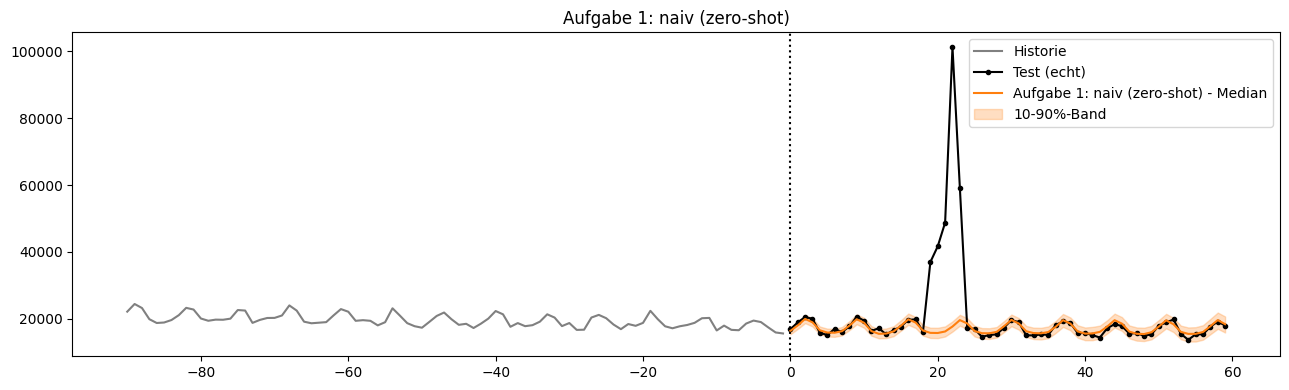

In [3]:
pipe = BaseChronosPipeline.from_pretrained('amazon/chronos-bolt-small', device_map='cpu')

# erstes Argument heißt 'inputs' (aktuelle Chronos-Version)
quantiles, mean = pipe.predict_quantiles(
    inputs=torch.tensor(y_train, dtype=torch.float32),
    prediction_length=H, quantile_levels=[0.1, 0.5, 0.9],
)
lo1     = quantiles[0, :, 0].numpy()
median1 = quantiles[0, :, 1].numpy()
hi1     = quantiles[0, :, 2].numpy()

m1 = print_metrics(y_test, median1, 'Aufgabe 1: naiv')
plot_forecast(y_train, y_test, median1, lo1, hi1, 'Aufgabe 1: naiv (zero-shot)')

**Kommentar:** Chronos ist zero-shot – die Punktprognose ist der Median (`quantiles[0,:,1]`), das Band kommt aus den Quantilen 0.1/0.9. Das naive Modell kennt den Kalender nicht und **verpasst den Black-Friday-Peak** im Test (die rote Spitze wird nicht getroffen).

---
## ✅ Lösung Aufgabe 2a – größeres Modell (`bolt-base`)

In [4]:
pipe_b = BaseChronosPipeline.from_pretrained('amazon/chronos-bolt-base', device_map='cpu')
q, _ = pipe_b.predict_quantiles(
    inputs=torch.tensor(y_train, dtype=torch.float32),
    prediction_length=H, quantile_levels=[0.1, 0.5, 0.9],
)
median_2a = q[0, :, 1].numpy()
m2a = print_metrics(y_test, median_2a, 'Aufgabe 2a: bolt-base')

Loading weights:   0%|          | 0/269 [00:00<?, ?it/s]

Aufgabe 2a: bolt-base        RMSE= 13146.2  MAE=  4059.1  MAPE= 10.0%


---
## ✅ Lösung Aufgabe 2b – Black Friday als Kovariate (Chronos-2)

Das ist das **Experten-Modell**: Wir geben dem Modell die bekannte Information „an diesen Tagen ist Black Friday" mit – auch für die Zukunft (`future_df`).

In [5]:
from chronos import Chronos2Pipeline

pipe2 = Chronos2Pipeline.from_pretrained('amazon/chronos-2', device_map='cpu')

context_df = pd.DataFrame({
    'id': 'skydrive',
    'timestamp': df['ds'][:-H].values,
    'target': y_train,
    'black_friday': df['black_friday'].to_numpy()[:-H],
})
future_df = pd.DataFrame({
    'id': 'skydrive',
    'timestamp': df['ds'][-H:].values,
    'black_friday': df['black_friday'].to_numpy()[-H:],
})

pred_df = pipe2.predict_df(
    context_df, future_df=future_df, prediction_length=H,
    quantile_levels=[0.1, 0.5, 0.9],
    id_column='id', timestamp_column='timestamp', target='target',
)
median_2b = pred_df['0.5'].to_numpy()
m2b = print_metrics(y_test, median_2b, 'Aufgabe 2b: Chronos-2 + Black Friday')

Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

Aufgabe 2b: Chronos-2 + Black Friday RMSE=  4924.7  MAE=  1386.8  MAPE=  4.2%


---
## 📊 Showdown & Fazit

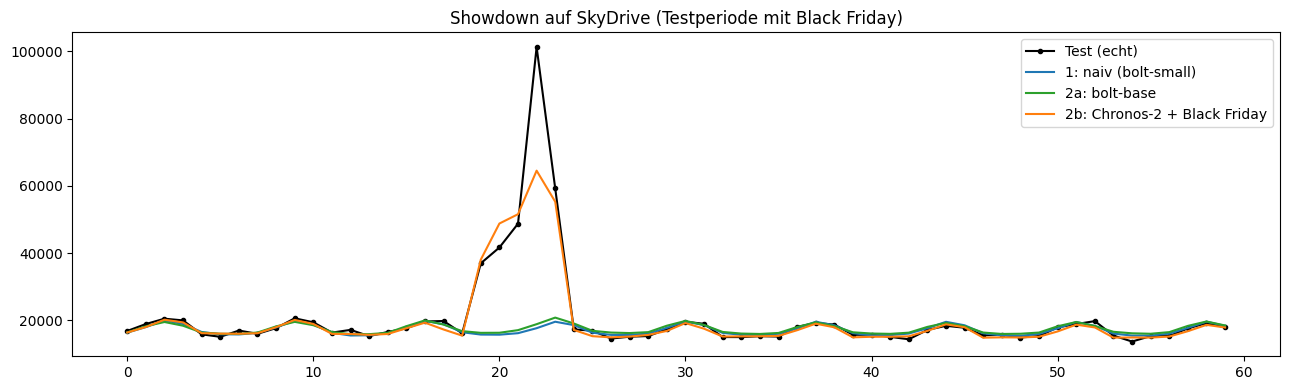

,RMSE,MAE,MAPE
label,,,
Aufgabe 1: naiv,13386.1,3955.1,9.1
Aufgabe 2a: bolt-base,13146.2,4059.1,10.0
Aufgabe 2b: Chronos-2 + Black Friday,4924.7,1386.8,4.2


In [6]:
xf = np.arange(H)
plt.figure(figsize=(13, 4))
plt.plot(xf, y_test, color='black', marker='.', label='Test (echt)')
plt.plot(xf, median1,   color='C0', label='1: naiv (bolt-small)')
plt.plot(xf, median_2a, color='C2', label='2a: bolt-base')
plt.plot(xf, median_2b, color='C1', label='2b: Chronos-2 + Black Friday')
plt.title('Showdown auf SkyDrive (Testperiode mit Black Friday)')
plt.legend(); plt.tight_layout(); plt.show()

pd.DataFrame([m1, m2a, m2b]).set_index('label').round(1)

**Kommentar:** Das größere Modell (2a) hilft meist nur leicht – es kennt den Black Friday weiterhin nicht. Erst die **Kovariate** (2b) sagt dem Modell explizit, *wann* der Peak kommt, und senkt den Fehler im Black-Friday-Fenster deutlich. Das ist das direkte Chronos-Gegenstück zu Prophets „Experten-Modell mit Black Friday".

---
## 💬 Antworten zu den Diskussionsfragen

**1. Warum funktioniert Chronos ohne `fit()` und ohne Feiertage?**
Chronos ist auf sehr vielen Zeitreihen **vortrainiert** und hat typische Muster (Trend, Wochen-/Jahressaison) bereits gelernt. Es überträgt dieses Wissen *zero-shot* auf neue Reihen – ähnlich wie ein Sprachmodell Texte vervollständigt, ohne für jeden Text neu trainiert zu werden.

**2. Was bringt am meisten?**
Mehr Kontext und ein größeres Modell helfen bei den „normalen" Mustern. Den **einmaligen** Black-Friday-Peak trifft aber nur die **Kovariate**, weil das Modell den Kalender sonst nicht kennt.

**3. Prophet oder Chronos?**
- **Prophet:** wenn Erklärbarkeit zählt, Domänenwissen (Feiertage, Aktionen) klar einbaubar ist, wenig Rechenleistung da ist.
- **Chronos:** wenn schnell ein starker Forecast ohne Feature-Engineering gebraucht wird, viele Reihen parallel zu prognostizieren sind, und ein Black-Box-Modell akzeptabel ist.